In [1]:
import pandas as pd
import time
from Neural_networks import *
import matplotlib.pyplot as plt
from tqdm import tqdm

Matplotlib is building the font cache; this may take a moment.


In [2]:
############## Helper functions for comparison #######################################################################

def comparing_methods_initialization_after_pruning(amount_of_repeats, rounds, method_1, method_2):
    beginning = time.time() #XXx remove
    df_accuracies_method_1 = pd.DataFrame()
    df_accuracies_method_2 = pd.DataFrame()
    
    for i in tqdm(range(amount_of_repeats)):
        print(f"\nIteration for average : {i + 1}/{amount_of_repeats}")
        #All the iterations for the first method
        df_acc_method_1,_ = method_1()
        for j in range (len(df_acc_method_1)):
            df_acc_method_1[j]['Iteration'] = i + 1
        df_accuracies_method_1 = pd.concat([df_accuracies_method_1, pd.DataFrame(df_acc_method_1)])

        #All the iterations for the LTH method
        df_acc_method_2,_ = method_2()
        for j in range (len(df_acc_method_2)):
            df_acc_method_2[j]['Iteration'] = i + 1
        df_accuracies_method_2 = pd.concat([df_accuracies_method_2, pd.DataFrame(df_acc_method_2)])

    df_avg_accuracies_method_1 = []
    df_avg_accuracies_method_2 = []
    for pruning_round in range (rounds): #xxx - find rounds in another way. 
        for df, df_avg in [(df_accuracies_method_1, df_avg_accuracies_method_1), (df_accuracies_method_2, df_avg_accuracies_method_2)]:
            df_round = df[df['Round']=='Round '+str(pruning_round)]
            round_avg_of_test_acc = df_round['Test Accuracy (with training)'].mean()
            min_test_acc = df_round['Test Accuracy (with training)'].min()
            max_test_acc = df_round['Test Accuracy (with training)'].max()
            pruning_perc = df_round['Pruning percentage'].mean()

            round_avg_info = {'Round' : 'Round '+str(pruning_round), 
                            'Pruning Percentage' : pruning_perc,
                            'Avg Test Accuracy' : round_avg_of_test_acc,
                            'Min Test Accuracy' : min_test_acc,
                            'Max Test Accuracy' : max_test_acc}
            df_avg.append(round_avg_info)

    df_avg_accuracies_method_1 = pd.DataFrame(df_avg_accuracies_method_1)
    df_avg_accuracies_method_2 = pd.DataFrame(df_avg_accuracies_method_2)

    print((time.time()- beginning)/60)#XXx remove
    
    return df_avg_accuracies_method_1, df_avg_accuracies_method_2



def comparing_methods_plotting(df_avg_accuracies_method_1, df_avg_accuracies_method_2, method_1_name, method_2_name):

    plt.errorbar(df_avg_accuracies_method_1['Pruning Percentage'],
                df_avg_accuracies_method_1['Avg Test Accuracy'],
                yerr=[df_avg_accuracies_method_1['Avg Test Accuracy'] - df_avg_accuracies_method_1['Min Test Accuracy'],
                        df_avg_accuracies_method_1['Max Test Accuracy'] - df_avg_accuracies_method_1['Avg Test Accuracy']],
                label = method_1_name)
    plt.errorbar(df_avg_accuracies_method_2['Pruning Percentage'],
                df_avg_accuracies_method_2['Avg Test Accuracy'],
                yerr=[df_avg_accuracies_method_2['Avg Test Accuracy'] - df_avg_accuracies_method_2['Min Test Accuracy'],
                        df_avg_accuracies_method_2['Max Test Accuracy'] - df_avg_accuracies_method_2['Avg Test Accuracy']],
                label = method_2_name)
    
    plt.xlabel("Pruning Percentage")
    plt.ylabel("Test Accuracy")
    plt.title(f"Comparing the initialization methods : {method_1_name} vs {method_2_name}") #xxx Change title 
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"plots/comparing_initialization_post_pruning_{method_1_name.replace(' ','')}_vs_{method_2_name.replace(' ','')}.png") #xxx Change file title 



In the Lottery Ticket Hypothesis paper, the authors propose two different iterative pruning strategies to find the winning tickets. 

Strategy 1: Iterative pruning with resetting.
1. Randomly initialize a neural network f(x; m⊙θ) where θ= θ_0 and m= 1^(|θ|) is a mask.
2. Train the network for jiterations, reaching parameters m⊙θ_j.
3. Prune s% of the parameters, creating an updated mask m' where Pm' = (Pm - s)%.
4. Reset the weights of the remaining portion of the network to their values in θ0. That is, let
θ= θ_0.
5. Let m = m' and repeat steps 2 through 4 until a sufficiently pruned network has been
obtained.


Strategy 2: Iterative pruning with continued training.
1. Randomly initialize a neural network f(x; m⊙θ) where θ= θ_0 and m= 1^(|θ|) is a mask.
2. Train the network for jiterations.
3. Prune s% of the parameters, creating an updated mask m' where Pm' = (Pm - s)%.
4. Let m= m' and repeat steps 2 and 3 until a sufficiently pruned network has been obtained.
5. Reset the weights of the remaining portion of the network to their values in θ_0. That is, let
θ= θ_0.

The difference between the two strategies is the reinitialization of the weights after pruning. 
At step 3, s% of the parameters are pruned, and we create a mask. In strategy 1, the unmasked 
weights are being reset to their value from θ_0 and then the pruning steps are being repeated.
In strategy 2, after pruning, the weights are kept at their post-trained values to then be 
trained again with only the unpruned weights. It is at the end when the model has been sufficiently 
pruned that we train it one final time with θ_0 .

According to the paper, the first strategy offers better results. In this section, we propose to 
check this claim.

In [3]:
############## Comparing the two strategies in the appendix ##########################################################

total_prune_percent = 99
rounds = 7
amount_of_repeats = 5

def method_1_LTH_strategy1():
    return iterative_pruning_MNIST(total_prune_percent=total_prune_percent, rounds=rounds, LTH=True)

In [4]:
def method_2_LTH_strategy2():
    return iterative_pruning_MNIST(total_prune_percent=total_prune_percent, rounds=rounds, strategy_1=False)

  0%|          | 0/5 [00:00<?, ?it/s]


Iteration for average : 1/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 97.32%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.48% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 96.37%

--- Round 2/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 73.17%
Accuracy after retraining: 96.88%

--- Round 3/7 ---
Current pruning percentage (Method 1): 86.11%
Pruning threshold: 0.06
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 86.10%
Accuracy after retraining: 97.07%

--- Round 4/7 ---
Current pruning percentage (Method 1): 92.80%
Pruning threshold: 0.13
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 92.80%
Ac

 20%|██        | 1/5 [1:05:19<4:21:16, 3919.13s/it]

Accuracy after retraining: 97.58%

Iteration for average : 2/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 97.35%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.48% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 96.64%

--- Round 2/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 73.17%
Accuracy after retraining: 96.82%

--- Round 3/7 ---
Current pruning percentage (Method 1): 86.11%
Pruning threshold: 0.07
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 86.10%
Accuracy after retraining: 97.12%

--- Round 4/7 ---
Current pruning percentage (Method 1): 92.80%
Pruning threshold: 0.13
Layer fc2.bias: 10 weights, 0 zeros
Cur

 40%|████      | 2/5 [2:10:50<3:16:19, 3926.48s/it]

...

Accuracy after retraining: 97.12%

Iteration for average : 4/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 97.6%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.48% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 95.86%

--- Round 2/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 73.17%
Accuracy after retraining: 96.93%

--- Round 3/7 ---
Current pruning percentage (Method 1): 86.11%
Pruning threshold: 0.05
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 86.10%
Accuracy after retraining: 96.63%

--- Round 4/7 ---
Current pruning percentage (Method 1): 92.80%
Pruning threshold: 0.12
Layer fc2.bias: 10 weights, 0 zeros
Curr

 80%|████████  | 4/5 [4:23:04<1:05:56, 3956.09s/it]

Accuracy after retraining: 96.77%

Iteration for average : 5/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 97.66%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.48% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 95.82%

--- Round 2/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 73.17%
Accuracy after retraining: 96.63%

--- Round 3/7 ---
Current pruning percentage (Method 1): 86.11%
Pruning threshold: 0.05
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 86.10%
Accuracy after retraining: 96.66%

--- Round 4/7 ---
Current pruning percentage (Method 1): 92.80%
Pruning threshold: 0.11
Layer fc2.bias: 10 weights, 0 zeros
Cur

100%|██████████| 5/5 [23:37:10<00:00, 17006.10s/it]

Accuracy after retraining: 97.40%
1417.1773234287898


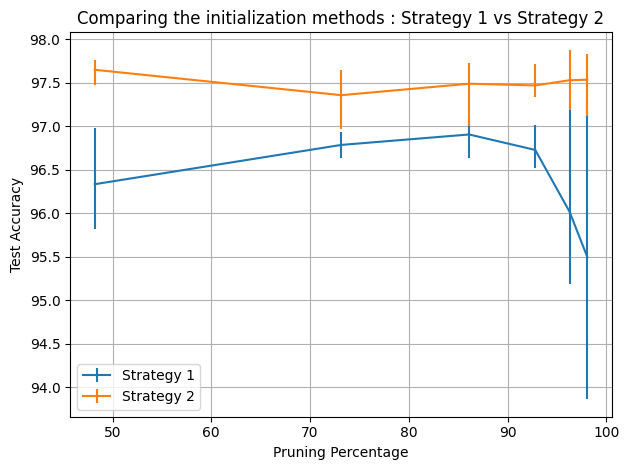

In [5]:
df_avg_acc_method_1, df_avg_acc_method_2 = comparing_methods_initialization_after_pruning(amount_of_repeats = amount_of_repeats, rounds = rounds, method_1=method_1_LTH_strategy1, method_2=method_2_LTH_strategy2)
comparing_methods_plotting(df_avg_acc_method_1, df_avg_acc_method_2, "Strategy 1", "Strategy 2")

On page 2 of the Lottery Ticket Hypothesis paper, the authors claim that the strength of their unique pruning technique
comes from the fact that after pruning, the weights are set back to their original weights (from the dense model). From
there, the model is retrained and the test accuracies are as good, if not better then they were originally.

We want to test this theory by randomly reinitializing the not-pruned weights, and seeing the test accuracies.

In [6]:
############## Comparing initialization after pruning ##########################################################
total_prune_percent = 99
rounds = 7
amount_of_repeats = 5

def method_1_LTH():
    return iterative_pruning_MNIST(total_prune_percent=total_prune_percent, rounds=rounds, LTH=True)


In [7]:
def method_2_random():
    return iterative_pruning_MNIST(total_prune_percent=total_prune_percent, rounds=rounds, LTH=False)

In [8]:
df_avg_acc_method_1, df_avg_acc_method_2 = comparing_methods_initialization_after_pruning(amount_of_repeats = amount_of_repeats, rounds = rounds, method_1=method_1_LTH, method_2=method_2_random)
comparing_methods_plotting(df_avg_acc_method_1, df_avg_acc_method_2, "LTH", "Random Initialisation")

  0%|          | 0/5 [00:00<?, ?it/s]


Iteration for average : 1/5

Step 1 and 2: training the randomly initialized neural network for MNIST.
Initial accuracy : 97.11%.

Step 4: Creating the Winning ticket
Number of zeros before pruning: 0
At each round, we are pruning : 0.48% of the weights.

--- Round 1/7 ---
Current pruning percentage (Method 1): 48.21%
Pruning threshold: 0.02
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 48.20%
Accuracy after retraining: 96.36%

--- Round 2/7 ---
Current pruning percentage (Method 1): 73.17%
Pruning threshold: 0.03
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 73.17%
Accuracy after retraining: 96.93%

--- Round 3/7 ---
Current pruning percentage (Method 1): 86.11%
Pruning threshold: 0.06
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 86.10%
Accuracy after retraining: 97.01%

--- Round 4/7 ---
Current pruning percentage (Method 1): 92.80%
Pruning threshold: 0.13
Layer fc2.bias: 10 weights, 0 zeros
Current pruning percentage: 92.80%
Ac

  0%|          | 0/5 [40:30<?, ?it/s]


KeyboardInterrupt: 

### Test pour les données CIFAR 

In [ ]:
# Configuration "Micro-Expérience" pour CPU
# On fait le minimum vital pour voir si le code plante ou tourne
cifar_test_repeats = 1      # Une seule répétition pour tester
cifar_test_rounds = 1       # Un seul round d'élagage
cifar_test_epochs = 2       # 2 epochs seulement (assez pour voir la loss bouger, pas pour converger)
cifar_prune_rate = 20       # On élague 20% juste pour tester le mécanisme


In [ ]:
# Wrapper 1 : Winning Ticket sur CIFAR
def method_cifar_lth():
    # Note : iterative_pruning_CIFAR utilise votre classe SimpleCNN par défaut
    return iterative_pruning_CIFAR(
        total_prune_percent=cifar_prune_rate,
        rounds=cifar_test_rounds,
        epochs_per_round=cifar_test_epochs,
        lr=0.001,
        LTH=True
    )

In [ ]:
# Wrapper 2 : Random Initialization sur CIFAR (Control)
def method_cifar_random():
    return iterative_pruning_CIFAR(
        total_prune_percent=cifar_prune_rate,
        rounds=cifar_test_rounds,
        epochs_per_round=cifar_test_epochs,
        lr=0.001,
        LTH=False
    )

In [ ]:
# Lancement de la comparaison (Réutilisation de votre fonction générique)
# Cela va entraîner le modèle LTH, puis le modèle Random, et comparer les deux.
df_cifar_lth, df_cifar_rand = comparing_methods_initialization_after_pruning(
    amount_of_repeats=cifar_test_repeats, 
    rounds=cifar_test_rounds, 
    method_1=method_cifar_lth, 
    method_2=method_cifar_random
)

In [ ]:
# Génération du graphique de test
comparing_methods_plotting(
    df_cifar_lth, 
    df_cifar_rand, 
    "CIFAR SimpleCNN (Ticket)", 
    "CIFAR SimpleCNN (Random)"
)

## 2. Phase 2 : Extension et Analyse Comparative
Nous cherchons à comparer l'efficacité de la méthode "Lottery Ticket" par rapport aux méthodes d'élagage standard (Fine-Tuning), comme discuté dans l'Annexe B du papier[cite: 651].

* **Comparaison Stratégie 1 vs Stratégie 2 :**
   -  **Stratégie 1 (Winning Ticket) :** Après élagage, on **réinitialise** les poids à $\theta_0$ avant de ré-entraîner .
   -  **Stratégie 2 (Standard Fine-Tuning) :** Après élagage, on **conserve** les poids entraînés $\theta_j$ et on continue l'entraînement.
* **Objectif :** Vérifier si le "Resetting" permet effectivement d'atteindre une meilleure précision ou convergence sur des réseaux très clairsemés.

In [ ]:
########################### PHASE 2: COMPARISON STRATEGY 1 vs 2 (MNIST) ###########################

print("\n" + "="*50)
print("STARTING PHASE 2: STRATEGY 1 (RESET) VS STRATEGY 2 (FINE-TUNE) ON MNIST")
print("="*50)

# Paramètres pour une expérience significative sur CPU (MNIST est rapide)
# On veut voir la divergence quand le réseau devient très vide (sparsity élevée)
mnist_repeats = 3       # 3 répétitions pour avoir une moyenne fiable
mnist_rounds = 15       # 15 rounds pour élaguer agressivement (~3-4% de poids restants)
mnist_epochs = 5        # Assez pour converger sur MNIST

def method_mnist_strategy_1():
    # Strategy 1 = Reset to Theta_0 (Winning Ticket)
    return iterative_pruning_MNIST(
        total_prune_percent=20, # Taux par round (selon le papier)
        rounds=mnist_rounds,
        epochs_per_round=mnist_epochs,
        lr=0.0012,              # Learning rate suggéré par l'Appendix G [cite: 1477]
        LTH=True,
        strategy_1=True
    )

def method_mnist_strategy_2():
    # Strategy 2 = Keep Theta_j (Standard Fine-Tuning)
    return iterative_pruning_MNIST(
        total_prune_percent=20,
        rounds=mnist_rounds,
        epochs_per_round=mnist_epochs,
        lr=0.0012,
        LTH=True,
        strategy_1=False     # C'est ici que ça change !
    )

# Lancement de la comparaison
df_strat1, df_strat2 = comparing_methods_initialization_after_pruning(
    amount_of_repeats=mnist_repeats,
    rounds=mnist_rounds,
    method_1=method_mnist_strategy_1,
    method_2=method_mnist_strategy_2
)

# Plotting
comparing_methods_plotting(
    df_strat1,
    df_strat2,
    "Winning Ticket (Reset)",
    "Standard Pruning (Fine-tune)"
)